# HDB Resale Price — Exploratory Data Analysis

**Business problem.** Cataria Property Solutions wants consistent, data-driven HDB resale
valuations. We predict `resale_price` (a continuous dollar value) from transaction
attributes, so this is a **regression** problem.

**Goal of this notebook.** Understand the raw data, surface and document every data-quality
issue, engineer the features the model will use, study how each feature relates to the
target (descriptively *and* with formal statistical tests), and end with an explicit list of
preprocessing decisions and modelling hypotheses. Every cleaning rule below is mirrored in the
pipeline (`src/data_preparation.py`) so the analysis and the model stay in sync. Selected
summary tables are also written to `./reports/` so they can be reviewed without rerunning.

## 1. Setup and data loading

In [1]:
import sys, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from scipy import stats
from sklearn.linear_model import LinearRegression

sys.path.append(".")            # so we can import the project's own pipeline code
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

REPORTS = Path("reports"); REPORTS.mkdir(exist_ok=True)   # persisted EDA summaries

with open("src/config.yaml") as f:
    config = yaml.safe_load(f)

TARGET = config["target_column"]
df = pd.read_csv(config["file_path"])
print("Shape:", df.shape, "| target:", TARGET)
df.head()

Shape: (88688, 14) | target: resale_price


,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
0,1,2018-05,5 ROOM,118,PASIR RIS ST 11,07 TO 09,123.0,1989,70 years 03 months,488000.0,17,5,PASIR RIS,Improved
1,2,2016-10,4 ROOM,101,RIVERVALE WALK,01 TO 03,100.0,1999,81,345000.0,21,8,SENGKANG,Model A
2,3,2018-10,5 ROOM,688A,CHOA CHU KANG DR,19 TO 21,110.0,2002,82 years 06 months,370000.0,9,5,CHOA CHU KANG,Improved
3,4,2015-12,4 ROOM,130,LOR AH SOO,13 TO 15,103.0,1984,67,432000.0,12,8,HOUGANG,Model A
4,5,2017-09,5 ROOM,533,SERANGOON NTH AVE 4,07 TO 09,122.0,1992,74 years 02 months,500000.0,22,5,SERANGOON,Improved


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88688 entries, 0 to 88687
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   88688 non-null  int64  
 1   month                88688 non-null  str    
 2   flat_type            88688 non-null  str    
 3   block                88688 non-null  str    
 4   street_name          88688 non-null  str    
 5   storey_range         88688 non-null  str    
 6   floor_area_sqm       88688 non-null  float64
 7   lease_commence_date  88688 non-null  int64  
 8   remaining_lease      88688 non-null  str    
 9   resale_price         88688 non-null  float64
 10  town_id              88688 non-null  int64  
 11  flatm_id             88688 non-null  int64  
 12  town_name            87905 non-null  str    
 13  flatm_name           88174 non-null  str    
dtypes: float64(2), int64(4), str(8)
memory usage: 9.5 MB


In [3]:
# Early numeric summary — spot suspicious ranges (e.g. negative years) before cleaning.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,88688.0,42233.303739,24376.312037,1.0,21136.75,42228.5,63339.25,84465.0
floor_area_sqm,88688.0,97.520444,24.197379,31.0,76.00,96.0,112.00,280.0
lease_commence_date,88688.0,1570.225352,1226.315949,-2016.0,1980.00,1988.0,2000.00,2016.0
resale_price,88688.0,438679.303299,146670.254508,160000.0,335000.00,408000.0,505000.00,1200000.0
town_id,88688.0,14.631337,8.032285,1.0,8.00,15.0,22.00,26.0
flatm_id,88688.0,8.889185,3.906898,1.0,5.00,8.0,12.00,21.0


**First observations.**

- ~88.7k transactions, 14 columns. The target is `resale_price`.
- Numeric-looking: `floor_area_sqm`, `lease_commence_date`, `resale_price`, plus id-like
  `id`, `town_id`, `flatm_id`.
- Text/categorical: `month` (a `YYYY-MM` string), `flat_type`, `block`, `street_name`,
  `storey_range`, `remaining_lease`, `town_name`, `flatm_name`.
- The numeric summary already flags a problem: `lease_commence_date` has a **negative
  minimum**, which is impossible for a commencement year — a data-quality issue to confirm
  below. `month`, `storey_range` and `remaining_lease` are text encoding numeric/temporal
  information and will need engineering.

## 2. Data quality checks

In [4]:
# Missing values
missing = df.isna().sum()
missing[missing > 0].to_frame("missing_count").assign(
    pct=lambda d: (d["missing_count"] / len(df) * 100).round(2))

,missing_count,pct
town_name,783,0.88
flatm_name,514,0.58


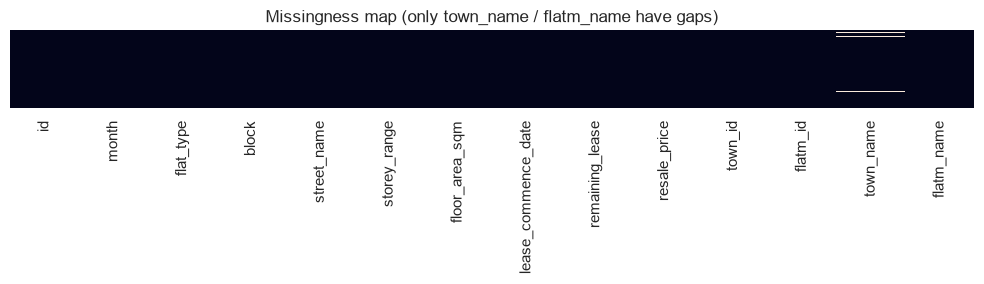

In [5]:
# Missingness heatmap — is missingness scattered or structured?
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, ax=ax)
ax.set_title("Missingness map (only town_name / flatm_name have gaps)")
plt.tight_layout(); plt.show()

In [6]:
# Exact duplicate rows
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated 'id' values :", df["id"].duplicated().sum())

Fully duplicated rows: 4223
Duplicated 'id' values : 4223


In [7]:
# Invalid / inconsistent values
print("Negative lease_commence_date values:", (df["lease_commence_date"] < 0).sum(),
      "| raw range:", df["lease_commence_date"].min(), "to", df["lease_commence_date"].max())
print("\nflat_type value counts (note the 'FOUR ROOM' typo):")
print(df["flat_type"].value_counts())

rl = df["remaining_lease"].astype(str)
print("\nremaining_lease is stored in TWO formats:")
print("  bare number  e.g. '81'                :", rl.str.match(r"^\d+$").sum())
print("  'X years Y months' e.g. '70 years 03 months':", rl.str.contains("year").sum())

Negative lease_commence_date values: 9394 | raw range: -2016 to 2016

flat_type value counts (note the 'FOUR ROOM' typo):
flat_type
4 ROOM              34741
3 ROOM              22557
5 ROOM              21484
EXECUTIVE            7017
FOUR ROOM            1824
2 ROOM                991
1 ROOM                 39
MULTI-GENERATION       35
Name: count, dtype: int64

remaining_lease is stored in TWO formats:
  bare number  e.g. '81'                : 36824
  'X years Y months' e.g. '70 years 03 months': 51864


**Data-quality findings.**

1. **Missing town/flat-model names** — `town_name` (783) and `flatm_name` (514) are missing,
   but each row still carries the numeric `town_id` / `flatm_id`. The missingness map shows the
   gaps are confined to those two columns, so we recover the names from an id→name mapping and
   drop no rows.
2. **Duplicate rows** — 4,223 fully duplicated transactions (same `id`), dropped.
3. **Corrupt `lease_commence_date`** — 9,394 rows have a *negative* year (down to −2016); the
   sign is a data-entry corruption, fixed with an absolute value.
4. **`flat_type` label inconsistency** — `"FOUR ROOM"` (1,824 rows) == `"4 ROOM"`; merged
   before encoding.
5. **Mixed `remaining_lease` format** — half bare (`"81"`), half verbose
   (`"70 years 03 months"`). One parser handles both and returns whole months.

## 3. Target variable analysis

count      88688.0
mean      438679.0
std       146670.0
min       160000.0
25%       335000.0
50%       408000.0
75%       505000.0
max      1200000.0
Name: resale_price, dtype: float64

Skew: 1.214


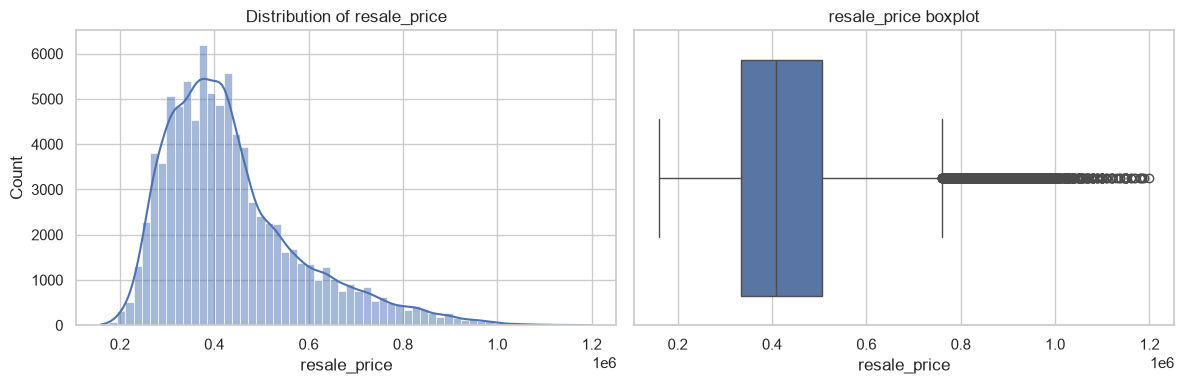

In [8]:
print(df[TARGET].describe().round(0))
print("\nSkew:", round(df[TARGET].skew(), 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], bins=60, kde=True, ax=ax[0])
ax[0].set_title("Distribution of resale_price")
sns.boxplot(x=df[TARGET], ax=ax[1])
ax[1].set_title("resale_price boxplot")
plt.tight_layout(); plt.show()

**Target observations.** Prices run from ~160k to 1.2M, mean ~439k above median ~408k, so the
distribution is **right-skewed** with a long upper tail (larger/executive flats). No missing or
non-positive prices. Because we lean on tree models (robust to skew), we model the raw price
rather than a log transform, but the skew is worth remembering when reading error metrics.

## 4. Feature engineering & validation

Rather than re-implement the transformations, we import the project's own `DataPreparation`
class and apply it, then verify the engineered columns on sample rows **and on hand-picked edge
cases**. This guarantees the EDA validates the exact logic the model will use.

In [9]:
from src.data_preparation import DataPreparation

prep = DataPreparation(config)
before_shape = df.shape
clean = prep.clean_data(df.copy())
print(f"Cleaning shape change: {before_shape} -> {clean.shape} "
      f"({before_shape[0] - clean.shape[0]} rows removed as duplicates)")
print("Cleaned columns:", list(clean.columns))
clean.head()

Cleaning shape change: (88688, 14) -> (84465, 10) (4223 rows removed as duplicates)
Cleaned columns: ['month', 'flat_type', 'storey_range', 'floor_area_sqm', 'lease_commence_date', 'resale_price', 'town_name', 'flatm_name', 'year', 'remaining_lease_months']


,month,flat_type,storey_range,floor_area_sqm,lease_commence_date,resale_price,town_name,flatm_name,year,remaining_lease_months
0,5,5 ROOM,8.0,123.0,1989,488000.0,PASIR RIS,Improved,2018,843.0
1,10,4 ROOM,2.0,100.0,1999,345000.0,SENGKANG,Model A,2016,972.0
2,10,5 ROOM,20.0,110.0,2002,370000.0,CHOA CHU KANG,Improved,2018,990.0
3,12,4 ROOM,14.0,103.0,1984,432000.0,HOUGANG,Model A,2015,804.0
4,9,5 ROOM,8.0,122.0,1992,500000.0,SERANGOON,Improved,2017,890.0


In [10]:
# Spot-check the engineered transforms against the raw values
check_clean = prep.clean_data(df.copy())
pd.DataFrame({
    "storey_range_raw": df["storey_range"].head(6).values,
    "storey_mid":       check_clean["storey_range"].head(6).values,
    "month_raw":        df["month"].head(6).values,
    "year":             check_clean["year"].head(6).values,
    "remaining_lease_raw":    df["remaining_lease"].head(6).values,
    "remaining_lease_months": check_clean["remaining_lease_months"].head(6).values,
})

,storey_range_raw,storey_mid,month_raw,year,remaining_lease_raw,remaining_lease_months
0,07 TO 09,8.0,2018-05,2018,70 years 03 months,843.0
1,01 TO 03,2.0,2016-10,2016,81,972.0
2,19 TO 21,20.0,2018-10,2018,82 years 06 months,990.0
3,13 TO 15,14.0,2015-12,2015,67,804.0
4,07 TO 09,8.0,2017-09,2017,74 years 02 months,890.0
5,04 TO 06,5.0,2018-09,2018,61 years 04 months,736.0


In [11]:
# Edge-case validation — prove the trickiest parser branches behave as intended.
edge = {
    "storey '01 TO 03' -> 2":       prep._convert_storey_range("01 TO 03") == 2.0,
    "storey '49 TO 51' -> 50":      prep._convert_storey_range("49 TO 51") == 50.0,
    "lease '61 years 04 months'":   prep._extract_lease_info("61 years 04 months") == 61*12+4,
    "lease bare '67' -> 804":       prep._extract_lease_info("67") == 67*12,
    "lease '90 years' (no months)": prep._extract_lease_info("90 years") == 90*12,
    "lease missing -> NaN":         np.isnan(prep._extract_lease_info(np.nan)),
}
for name, ok in edge.items():
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")
assert all(edge.values())

[PASS] storey '01 TO 03' -> 2
[PASS] storey '49 TO 51' -> 50
[PASS] lease '61 years 04 months'
[PASS] lease bare '67' -> 804
[PASS] lease '90 years' (no months)
[PASS] lease missing -> NaN


**Validation.** `storey_range` becomes its band midpoint, `month` becomes numeric
`year` + `month`, and both `remaining_lease` formats resolve to a single integer. The
edge-case checks confirm the boundary bands, the bare-number branch, the months-absent branch,
and the missing-value branch all behave correctly. High-cardinality address fields and id
columns are dropped in the same step.

## 5. Categorical feature profiling


flat_type — 8 categories
flat_type
4 ROOM              34741
3 ROOM              22557
5 ROOM              21484
EXECUTIVE            7017
FOUR ROOM            1824
2 ROOM                991
1 ROOM                 39
MULTI-GENERATION       35

town_name — 26 categories
town_name
JURONG WEST    6865
WOODLANDS      6575
SENGKANG       6481
TAMPINES       5893
YISHUN         5124
BEDOK          4993
PUNGGOL        4682
HOUGANG        4303

flatm_name — 21 categories
flatm_name
Model A              27536
Improved             22363
New Generation       13676
Premium Apartment     9051
Simplified            3888
Apartment             3384
Maisonette            2560
Standard              2492


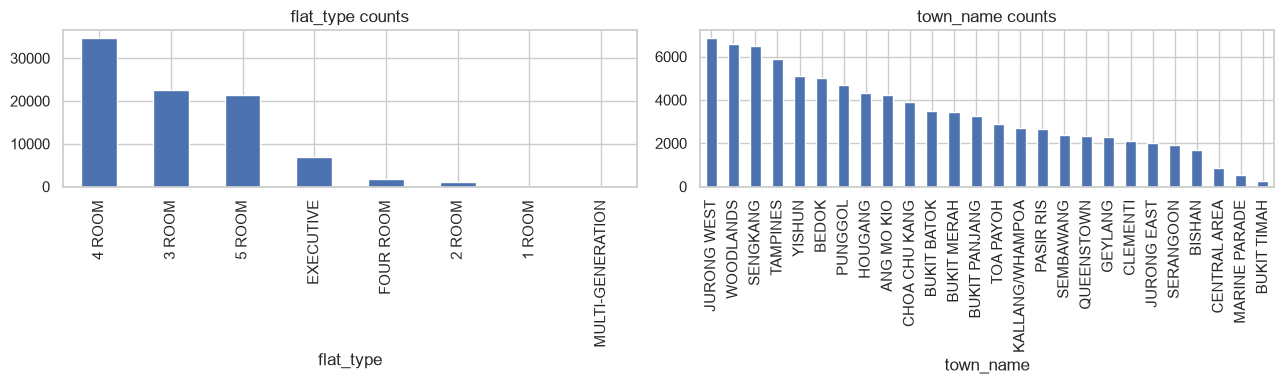

In [12]:
for col in ["flat_type", "town_name", "flatm_name"]:
    vc = df[col].value_counts(dropna=False)
    print(f"\n{col} — {df[col].nunique()} categories")
    print((vc.head(8)).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df["flat_type"].value_counts().plot(kind="bar", ax=ax[0], title="flat_type counts")
df["town_name"].value_counts().plot(kind="bar", ax=ax[1], title="town_name counts")
plt.tight_layout(); plt.show()

**Categorical observations.**

- **`flat_type`** is dominated by 3/4/5-ROOM; `1 ROOM` (39) and `MULTI-GENERATION` (35) are very
  rare. It has a natural size ordering → **ordinal-encoded** (with `FOUR ROOM` merged).
- **`town_name`** (26) and **`flatm_name`** (21) are moderate-cardinality nominal fields → **one-hot
  encoded** (`handle_unknown="ignore"`).
- **`storey_range`** has 17 ordered bands → converted to a numeric midpoint.

## 6. High-cardinality & leakage checks

In [13]:
card = df.nunique().sort_values(ascending=False).to_frame("n_unique")
card["pct_of_rows"] = (card["n_unique"] / len(df) * 100).round(2)
card.to_csv(REPORTS / "cardinality.csv")
card

,n_unique,pct_of_rows
id,84465,95.24
resale_price,2494,2.81
block,2324,2.62
remaining_lease,654,0.74
street_name,535,0.60
floor_area_sqm,165,0.19
lease_commence_date,101,0.11
month,54,0.06
town_id,26,0.03
town_name,26,0.03


In [14]:
# Normalized frequency: do block / street_name behave like identifiers?
# If most categories appear ~once, their relative frequency ~ 1/N.
for col in ["block", "street_name"]:
    freq = df[col].value_counts(normalize=True)
    appears_once = (df[col].value_counts() == 1).mean()
    print(f"{col}: {df[col].nunique()} categories | "
          f"max relative freq = {freq.max():.4f} | "
          f"{appears_once*100:.1f}% of categories appear exactly once")
    freq.head(5).to_frame("relative_freq").to_csv(REPORTS / f"freq_{col}.csv")

block: 2324 categories | max relative freq = 0.0039 | 1.1% of categories appear exactly once
street_name: 535 categories | max relative freq = 0.0156 | 0.4% of categories appear exactly once


**Leakage / cardinality decision.** `id` is the true identifier (one value per row, relative
frequency ≈ 1/N). `block` (2,324) and `street_name` (535) are extreme high-cardinality location
labels: no category dominates — the **maximum relative frequency is well under 1%** — so one-hot
encoding them would add hundreds-to-thousands of sparse columns and let the model latch onto
individual addresses (a leakage-like effect that won't generalise). **Trade-off:** dropping them
discards fine-grained
micro-location signal, but that signal is largely captured — more robustly — by `town_name` and
`storey_range`, so the trade-off is worth it. `town_id`/`flatm_id` are kept only to back-fill
the names, then dropped.

## 7. Feature–target relationships

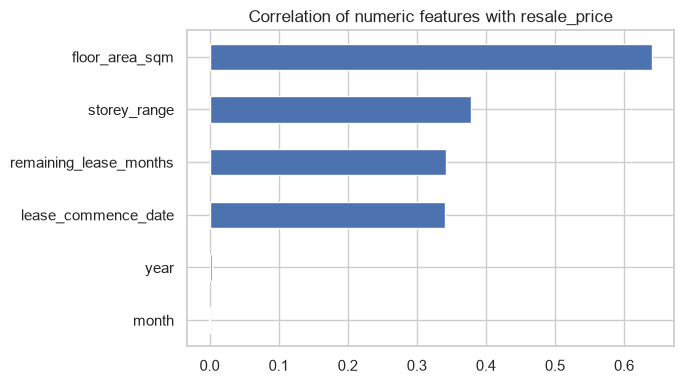

month                    -0.000
year                      0.003
lease_commence_date       0.341
remaining_lease_months    0.342
storey_range              0.378
floor_area_sqm            0.640
Name: resale_price, dtype: float64

In [15]:
num_cols = ["floor_area_sqm", "storey_range", "remaining_lease_months",
            "lease_commence_date", "year", "month"]
corr_target = clean[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
corr_target.plot(kind="barh", ax=ax, title=f"Correlation of numeric features with {TARGET}")
plt.tight_layout(); plt.show()
corr_target.round(3)

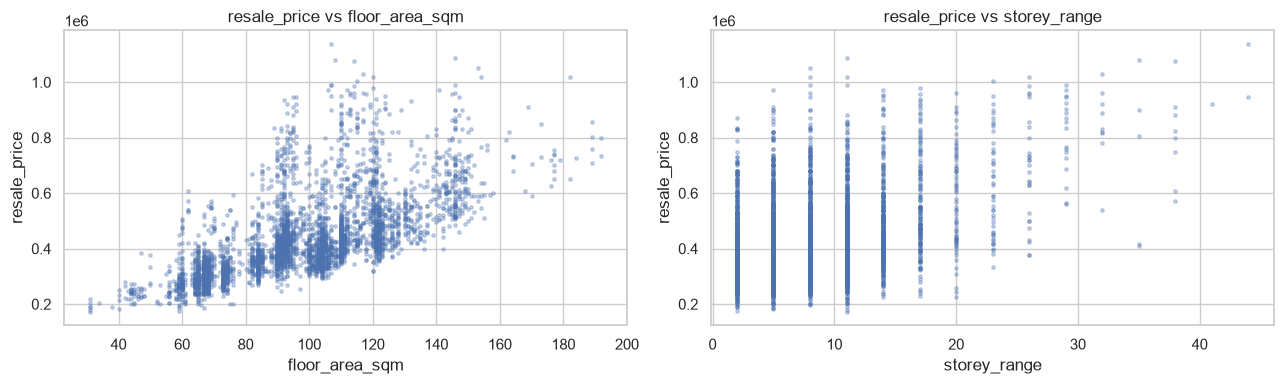

In [16]:
# Scatter plots for the two strongest numeric predictors — is the relationship linear/curved?
strong = corr_target.abs().sort_values(ascending=False).head(2).index.tolist()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, col in zip(ax, strong):
    sample = clean.sample(min(4000, len(clean)), random_state=0)
    a.scatter(sample[col], sample[TARGET], s=6, alpha=0.3)
    a.set_xlabel(col); a.set_ylabel(TARGET); a.set_title(f"{TARGET} vs {col}")
plt.tight_layout(); plt.show()

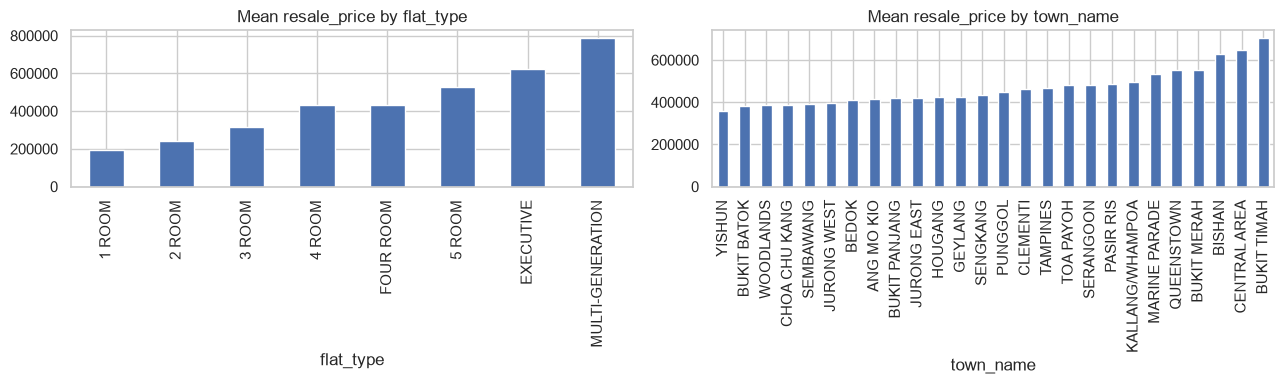

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df.groupby("flat_type")[TARGET].mean().sort_values().plot(
    kind="bar", ax=ax[0], title="Mean resale_price by flat_type")
df.groupby("town_name")[TARGET].mean().sort_values().plot(
    kind="bar", ax=ax[1], title="Mean resale_price by town_name")
plt.tight_layout(); plt.show()

In [18]:
# Formal test: does resale_price differ across categorical groups?
# One-way ANOVA (parametric) + Kruskal-Wallis (non-parametric fallback, since the target is
# skewed and group variances/sizes differ). eta-squared gives a model-free effect size.
def eta_squared(groups):
    all_vals = np.concatenate(groups)
    grand = all_vals.mean()
    ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
    ss_total = ((all_vals - grand) ** 2).sum()
    return ss_between / ss_total

for col in ["flat_type", "town_name"]:
    groups = [g[TARGET].to_numpy() for _, g in df.dropna(subset=[col]).groupby(col)]
    f_stat, p_anova = stats.f_oneway(*groups)
    h_stat, p_kw = stats.kruskal(*groups)
    print(f"{col}: ANOVA F={f_stat:,.1f} p={p_anova:.2e} | "
          f"Kruskal H={h_stat:,.1f} p={p_kw:.2e} | eta^2={eta_squared(groups):.3f}")

flat_type: ANOVA F=9,040.8 p=0.00e+00 | Kruskal H=48,313.2 p=0.00e+00 | eta^2=0.416
town_name: ANOVA F=729.1 p=0.00e+00 | Kruskal H=12,347.6 p=0.00e+00 | eta^2=0.172


**Relationship observations.**

- **`floor_area_sqm` is the strongest predictor** (r ≈ 0.64); the scatter is broadly linear with
  a widening spread at larger areas. `storey_range` (r ≈ 0.38) and `remaining_lease_months`
  (r ≈ 0.34) follow.
- **Formal categorical tests:** both ANOVA and the non-parametric Kruskal–Wallis return
  extremely small p-values for `flat_type` and `town_name`, i.e. the group differences in price
  are highly significant, and the **η²** effect sizes confirm these categoricals explain a large
  share of price variance. (ANOVA assumes normal, equal-variance groups, which the skewed target
  and unequal group sizes violate — hence we report Kruskal–Wallis alongside it and lean on the
  non-parametric result. A group with all-`NaN` prices would yield `NaN`; we guard by dropping
  rows missing the grouping column.)
- `year` / `month` correlate weakly with price (see §10) — the 2015–2019 window was fairly flat.

## 8. Outlier review (IQR)

In [19]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Full numeric outlier summary — count per feature AND how the outlier subset's mean target
# compares to the rest.
num_all = ["floor_area_sqm", "lease_commence_date", "resale_price",
           "storey_range", "remaining_lease_months", "year", "month"]
rows = []
cln = clean.copy()
for col in num_all:
    lo, hi = iqr_bounds(cln[col])
    mask = (cln[col] < lo) | (cln[col] > hi)
    rows.append({
        "feature": col,
        "n_outliers": int(mask.sum()),
        "pct": round(mask.mean() * 100, 2),
        "target_mean_outliers": round(cln.loc[mask, TARGET].mean(), 0) if mask.any() else np.nan,
        "target_mean_rest": round(cln.loc[~mask, TARGET].mean(), 0),
    })
outlier_summary = pd.DataFrame(rows)
outlier_summary.to_csv(REPORTS / "outlier_summary.csv", index=False)
outlier_summary

,feature,n_outliers,pct,target_mean_outliers,target_mean_rest
0,floor_area_sqm,269,0.32,729134.0,437883.0
1,lease_commence_date,0,0.00,NaN,438811.0
2,resale_price,3550,4.20,855882.0,420513.0
3,storey_range,2508,2.97,704333.0,430686.0
4,remaining_lease_months,0,0.00,NaN,438811.0
5,year,0,0.00,NaN,438811.0
6,month,0,0.00,NaN,438811.0


**Outlier decision.** Extending the IQR review across *all* numeric features shows the flagged
values are concentrated in the target and floor area, and the outlier subsets have a much higher
mean `resale_price` than the rest — i.e. they are genuine premium transactions (large
executive/multi-gen flats in central towns), not errors. We therefore **keep** them and rely on
tree models, which are robust to skew and extreme values, rather than clipping and discarding
signal.

## 9. Multicollinearity

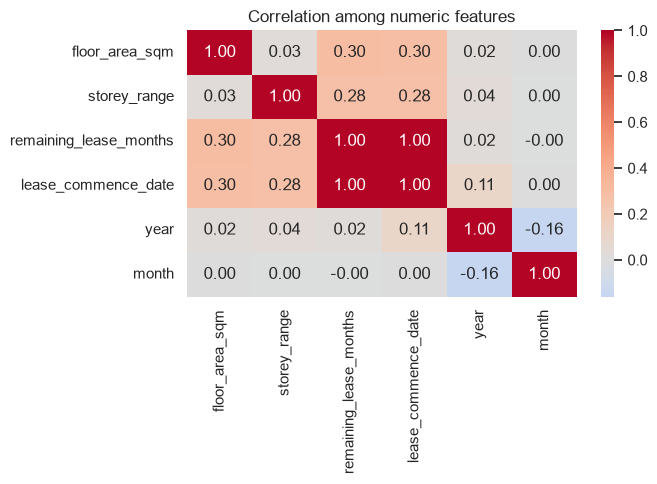

In [20]:
corr = clean[num_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation among numeric features")
plt.tight_layout(); plt.show()

In [21]:
# VIF (variance inflation factor) as a fuller multicollinearity diagnostic than pairwise r.
# VIF_i = 1 / (1 - R^2_i), where R^2_i is from regressing feature i on all other features.
def vif_table(frame, cols):
    out = []
    for col in cols:
        others = [c for c in cols if c != col]
        r2 = LinearRegression().fit(frame[others], frame[col]).score(frame[others], frame[col])
        out.append({"feature": col, "VIF": round(1.0 / (1.0 - r2), 2) if r2 < 1 else np.inf})
    return pd.DataFrame(out).sort_values("VIF", ascending=False)

vif = vif_table(clean[num_cols].dropna(), num_cols)
vif.to_csv(REPORTS / "vif.csv", index=False)
vif

,feature,VIF
3,lease_commence_date,1055.49
2,remaining_lease_months,1043.12
4,year,10.23
5,month,1.54
0,floor_area_sqm,1.10
1,storey_range,1.09


**Multicollinearity note.** The heatmap and the **VIF** table agree: `lease_commence_date` and
`remaining_lease_months` carry the highest inflation factors, because an older commencement year
mechanically means fewer months of lease left — they are near-redundant. Linear models feel this
(unstable coefficients), which is another reason to include tree/ensemble models that handle
correlated predictors gracefully. We keep both for now and flag the redundancy for modelling.

## 10. Time patterns

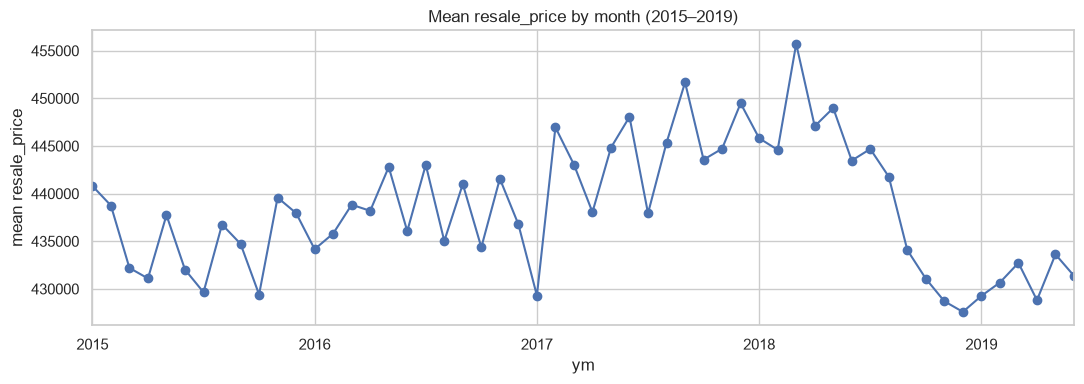

In [22]:
ts = df.copy()
ts["ym"] = pd.to_datetime(ts["month"], format="%Y-%m")
monthly = ts.groupby("ym")[TARGET].mean()

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(ax=ax, marker="o", title="Mean resale_price by month (2015–2019)")
ax.set_ylabel("mean resale_price"); plt.tight_layout(); plt.show()

**Time observation.** Over 2015–2019 the average price is broadly flat with mild wobble — no
strong trend or obvious seasonality — which is why raw `year` correlates only weakly with price.
`year`/`month` are kept as light features but are not major drivers here.

## 11. Conclusion — findings, preprocessing, and modelling hypotheses

| EDA finding | Preprocessing / modelling decision |
|---|---|
| 4,223 duplicate rows | Drop exact duplicates |
| `town_name`/`flatm_name` missing but ids present | Back-fill names from id→name map (no rows lost) |
| 9,394 negative `lease_commence_date` | Take absolute value |
| `FOUR ROOM` vs `4 ROOM` | Merge label before encoding |
| `remaining_lease` in two formats | Parse both → `remaining_lease_months` (int) |
| `storey_range` ordered text band | Convert to numeric midpoint |
| `month` = `YYYY-MM` text | Split into numeric `year` + `month` |
| `block`, `street_name`, `id` high-cardinality / identifiers | Drop (leakage & noise risk) |
| `flat_type` ordered, price-monotonic (large η²) | Ordinal-encode with explicit order |
| `town_name`, `flatm_name` unordered (large η²) | One-hot encode, `handle_unknown='ignore'` |
| `floor_area_sqm` strongest signal; skewed target; real outliers | Keep features; prefer tree/ensemble models |
| `lease_commence_date` ↔ `remaining_lease_months` collinear (high VIF) | Flag for modelling; favour tree models |

**Modelling hypotheses (stated before training):**

- `floor_area_sqm` will be the single most important feature, followed by `flat_type`,
  `town_name`, and `storey_range`.
- `year` and `month` will contribute little, given the flat 2015–2019 market.
- Tree ensembles (RandomForest / HistGradientBoosting) will clearly beat the linear models,
  because the strongest relationships involve interactions and mild non-linearity, and because
  the collinear lease features hurt linear coefficients but not trees.
- The DummyRegressor baseline (predict the mean) should sit near R² 0, confirming any real model
  adds value.

**Next (modelling).** Scale numerics, encode categoricals as above (all inside a
`ColumnTransformer`/`Pipeline` fit on training data only), impute for robustness, and compare a
`DummyRegressor` baseline against linear models **and** tree ensembles, tuned with
cross-validated search.